In [113]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [114]:
stock = "AAPL"
df = yf.download(stock, start="2020-01-01", end="2025-01-01")

/tmp/ipykernel_1411/3120860515.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [115]:
df = df[['Open', 'High', 'Low', 'Volume', 'Close']]

In [116]:
df["Prev_Close"] = df["Close"].shift(1)
df["Close_lag2"] = df["Close"].shift(2)
df["Close_lag3"] = df["Close"].shift(3)

In [117]:
df["MA5"] = df["Close"].rolling(5).mean()
df["MA10"] = df["Close"].rolling(10).mean()
df["MA20"] = df["Close"].rolling(20).mean()

In [118]:
df["STD5"] = df["Close"].rolling(5).std()

In [119]:
df["Target_Close"] = df["Close"].shift(-1)

In [120]:
df.dropna(inplace=True)

In [121]:
X = df[['Open','High','Low','Volume',
        'Prev_Close','Close_lag2','Close_lag3',
        'MA5','MA10','MA20','STD5']]

y = df["Target_Close"]

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    shuffle=False
)

Linear Regression

In [123]:
linear = LinearRegression()
linear.fit(X_train, y_train)

linear_pred = linear.predict(X_test)

Improved Random Forest

In [124]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [125]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Results")
    print("-"*35)
    print("MAE :", round(mean_absolute_error(y_true, y_pred), 2))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 2))
    print("R2 Score:", round(r2_score(y_true, y_pred), 4))

In [126]:
evaluate_model("Linear Regression", y_test, linear_pred)
evaluate_model("XGBoost", y_test, xgb_pred)



Linear Regression Results
-----------------------------------
MAE : 2.34
RMSE: 3.08
R2 Score: 0.9855

XGBoost Results
-----------------------------------
MAE : 20.54
RMSE: 27.43
R2 Score: -0.1531


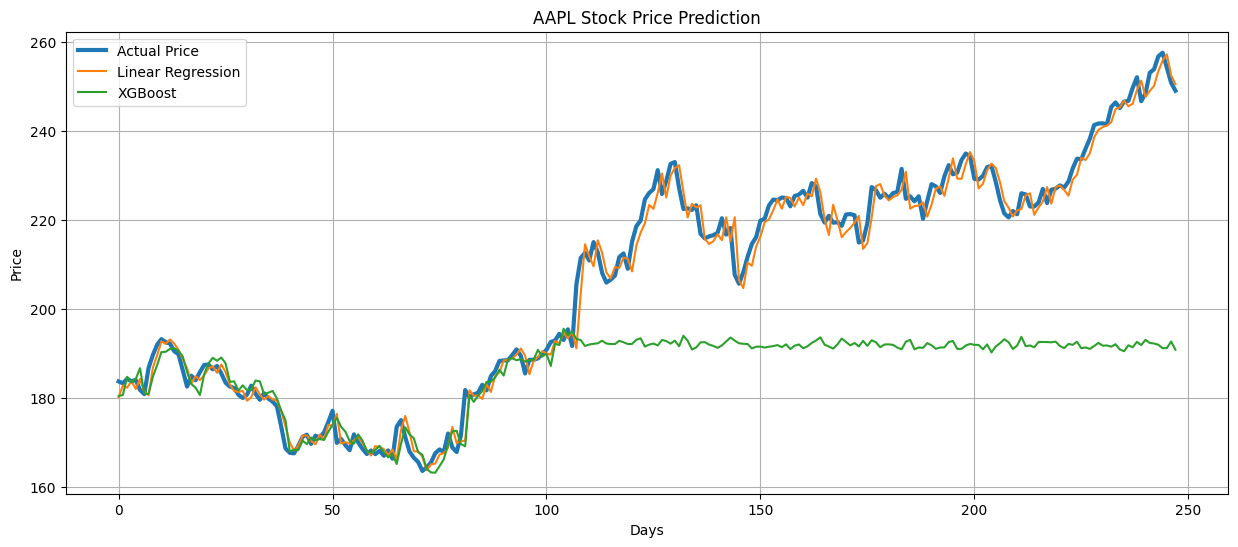

In [127]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values, label="Actual Price", linewidth=3)
plt.plot(linear_pred, label="Linear Regression")
plt.plot(xgb_pred, label="XGBoost")

plt.title(f"{stock} Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


In [128]:
latest_data = X.iloc[-1:].values

next_linear = linear.predict(latest_data)
next_xgb = xgb.predict(latest_data)

print("\nNext Day Predicted Closing Price")
print("--------------------------------")
print("Linear Regression:", round(next_linear[0], 2))
print("XGBoost          :", round(next_xgb[0], 2))


Next Day Predicted Closing Price
--------------------------------
Linear Regression: 250.56
XGBoost          : 190.78
